--- Model Evaluation ---
R-squared Score: 0.2249
RMSE: 5.2865



/var/folders/xg/slbv315n7nsgjg7ncb501lxc0000gn/T/ipykernel_1999/1262052195.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


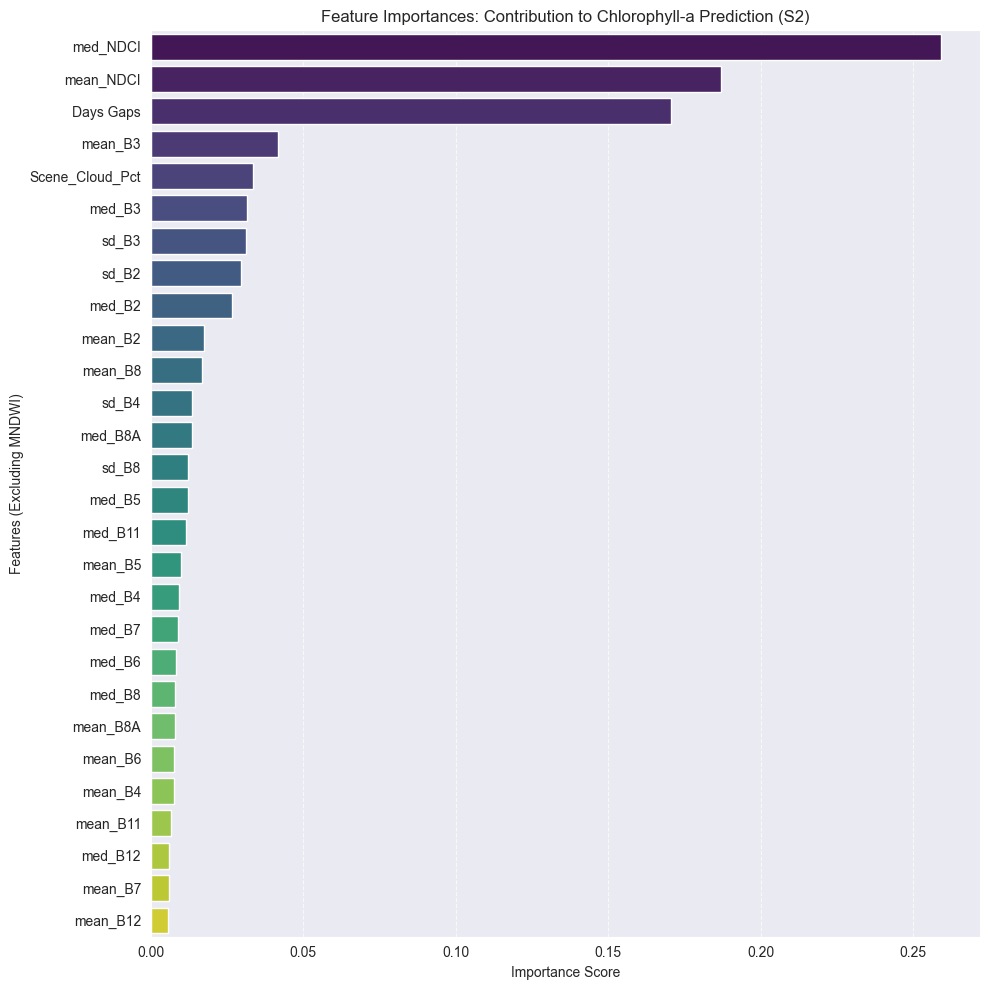

--- Feature Importance Ranking ---
        Feature  Importance
       med_NDCI    0.258977
      mean_NDCI    0.187040
      Days Gaps    0.170633
        mean_B3    0.041774
Scene_Cloud_Pct    0.033656
         med_B3    0.031706
          sd_B3    0.031198
          sd_B2    0.029714
         med_B2    0.026623
        mean_B2    0.017491
        mean_B8    0.016720
          sd_B4    0.013632
        med_B8A    0.013396
          sd_B8    0.012262
         med_B5    0.012166
        med_B11    0.011599
        mean_B5    0.010039
         med_B4    0.009140
         med_B7    0.008861
         med_B6    0.008331
         med_B8    0.008017
       mean_B8A    0.007815
        mean_B6    0.007707
        mean_B4    0.007457
       mean_B11    0.006542
        med_B12    0.006128
        mean_B7    0.005839
       mean_B12    0.005537


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('Tappan_S2_Bands_NDCI_MNDWI_30mBuffer.csv')

target_col = 'Target Variable(Chlorophyll-a)'

original_features = df.columns[11:35].tolist()

additional_features = ['mean_NDCI', 'med_NDCI', 'Scene_Cloud_Pct', 'Days Gaps']
feature_cols = original_features + additional_features

data = df[[target_col] + feature_cols].dropna()

X = data[feature_cols]
y = data[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- Model Evaluation ---")
print(f"R-squared Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}\n")

importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importances: Contribution to Chlorophyll-a Prediction (S2)')
plt.xlabel('Importance Score')
plt.ylabel('Features (Excluding MNDWI)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


print("--- Feature Importance Ranking ---")
print(feature_importance_df.to_string(index=False))